In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
model = ChatOpenAI()

In [3]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f'Generate a detailed outline for a blog on the topic - {title}'

    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']

    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

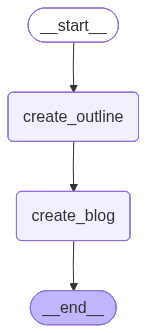

In [6]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()
workflow

In [7]:
initial_state = {'title': 'Cricket'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Cricket', 'outline': "I. Introduction\n   A. Brief history of cricket\n   B. Why cricket is popular worldwide\n\nII. Rules and Gameplay\n   A. Setting up a cricket field\n   B. The basic rules of cricket \n   C. Overview of different formats (Test, One Day, T20)\n\nIII. Equipment\n   A. Cricket bat\n   B. Cricket ball\n   C. Protective gear (pads, gloves, helmets)\n\nIV. Key players and teams \n   A. Overview of top cricket teams \n   B. Notable cricket players (past and present)\n   C. Women's cricket\n\nV. Major tournaments\n   A. ICC Cricket World Cup\n   B. ICC World T20\n   C. The Ashes\n\nVI. The impact of cricket \n   A. Social and cultural significance\n   B. Economic impact\n   C. Role of cricket in international diplomacy \n\nVII. Evolution and future of cricket\n   A. Changes in the game over the years\n   B. Challenges and opportunities facing cricket \n   C. Predictions for the future of the sport\n\nVIII. Conclusion\n   A. Recap of key points \n   B. Personal t